# Unsupervised Clustering

This notebook scores every test row with two unsupervised anomaly detectors, K-Means and DBSCAN, using the PCA-reduced clustering arrays written by the preprocessing notebook. Every device is scored on its own, and the pooled case is scored the same way.

Both detectors are fitted only on benign training data. Neither the label nor the test metadata is loaded anywhere in this notebook. `y_test.npy` and `test_metadata.parquet` are read only in the evaluation notebook that follows. No fitted K-Means or DBSCAN model is saved. Only the anomaly scores and predictions they produce are written to disk for evaluation in a later notebook.

In [1]:
# Standard library
import os
from pathlib import Path

# Move into the repository root so config.py and every relative path inside it resolve correctly
if not Path("config.py").exists():
    os.chdir("..")

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Local
import config

# Show every column when previewing a DataFrame, instead of truncating with "..."
pd.set_option("display.max_columns", None)

## Load the clustering arrays

The random seed is set so every random step below (the silhouette sample, in particular) is reproducible. Every chosen device, plus the pooled case, is loaded from the PCA-reduced clustering arrays that the preprocessing notebook wrote to `data/processed/`.for the next notebook to evaluate.

In [2]:
# Seed every random step in this notebook
np.random.seed(config.RANDOM_SEED)

# Load the PCA-reduced clustering arrays for every chosen device and the pooled case
entries = config.CHOSEN_DEVICES + ["_pooled"]
entry_arrays = {}
for entry in entries:
    entry_arrays[entry] = config.load_arrays(entry, "X_train_clustering", "X_val_clustering", "X_test_clustering")
    train_shape = entry_arrays[entry]["X_train_clustering"].shape
    val_shape = entry_arrays[entry]["X_val_clustering"].shape
    test_shape = entry_arrays[entry]["X_test_clustering"].shape
    print(f"{entry}: Train={train_shape}, Validate={val_shape}, Test={test_shape}")

Danmini_Doorbell: Train=(28276, 22), Validate=(6059, 22), Test=(46060, 22)
Philips_B120N10_Baby_Monitor: Train=(115598, 19), Validate=(24771, 19), Test=(64772, 19)
Provision_PT_838_Security_Camera: Train=(65796, 15), Validate=(14099, 15), Test=(54100, 15)
_pooled: Train=(84828, 19), Validate=(18177, 19), Test=(164932, 19)


## Confirm no label ever enters this notebook

The set of arrays loaded for every entry is asserted to contain exactly the three clustering arrays above.

In [3]:
# Every entry must have loaded exactly the three clustering arrays
expected_array_names = {"X_train_clustering", "X_val_clustering", "X_test_clustering"}
for entry, arrays in entry_arrays.items():
    assert set(arrays.keys()) == expected_array_names

## Choose the number of K-Means clusters by silhouette score

For every entry, a `KMeans` model is fit on the full benign training array for every k from `config.KMEANS_K_RANGE`. Each k is then scored by its silhouette score, computed on a fixed random sample of `config.SILHOUETTE_SAMPLE_SIZE` rows instead of the full training set, because the silhouette score compares every pair of sampled rows and so scales quadratically with the number of rows. This is not feasible at Philips' 115,598 training rows. The same random seed is passed for every k within an entry, so `silhouette_score` draws the identical sample of rows each time, keeping the comparison across k values fair.

Because every k is already fit on the *full* benign training array during the sweep, the model chosen at the end is the already-fitted model for the best k, and there is no need to fit it a second time.

In [4]:
# Fit K-Means for every k in a range and score each by silhouette on a fixed sample
def sweep_kmeans(X_train, k_range, sample_size, seed):
    results = {}
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(X_train)
        silhouette = silhouette_score(X_train, model.labels_, sample_size=sample_size, random_state=seed)
        results[k] = {"model": model, "silhouette": silhouette}
    return results

## Fit K-Means for every entry

The sweep above is run once per entry, and the k with the highest silhouette score is kept as that entry's chosen model. The full per-k silhouette table is also kept, since it is needed for the plot below.

In [5]:
# Sweep k for every entry and keep the model with the best silhouette score
kmeans_by_entry = {}
for entry, arrays in entry_arrays.items():
    sweep_results = sweep_kmeans(arrays["X_train_clustering"], config.KMEANS_K_RANGE, config.SILHOUETTE_SAMPLE_SIZE, config.RANDOM_SEED)
    best_k = max(sweep_results, key=lambda k: sweep_results[k]["silhouette"])
    kmeans_by_entry[entry] = {"model": sweep_results[best_k]["model"], "best_k": best_k, "silhouette_by_k": {k: result["silhouette"] for k, result in sweep_results.items()}}
    print(f"{entry}: Best k={best_k} (Silhouette={sweep_results[best_k]['silhouette']:.3f})")

Danmini_Doorbell: Best k=6 (Silhouette=0.503)
Philips_B120N10_Baby_Monitor: Best k=2 (Silhouette=0.907)
Provision_PT_838_Security_Camera: Best k=4 (Silhouette=0.588)
_pooled: Best k=5 (Silhouette=0.729)


## Plot the silhouette sweep

The silhouette score for every k considered is plotted for each entry, with the chosen k marked, so the choice can be checked by eye. This plot is saved for every entry, including the pooled case.

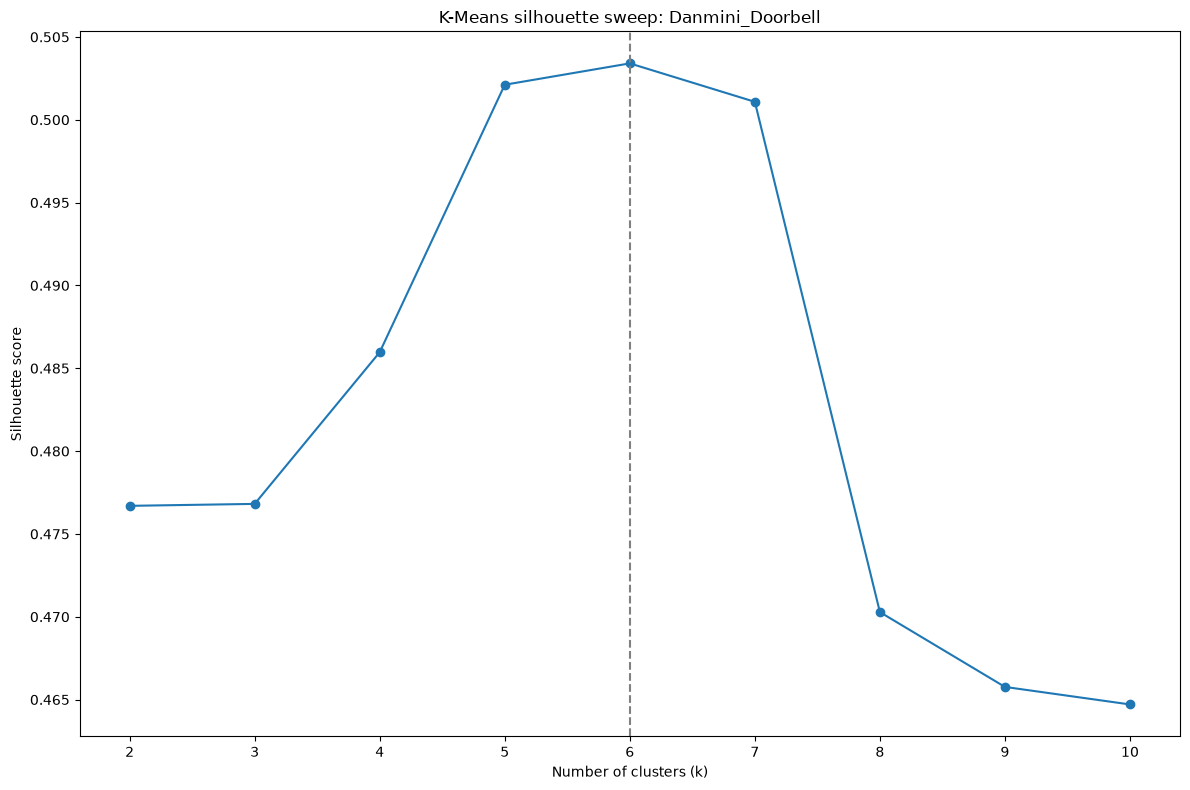

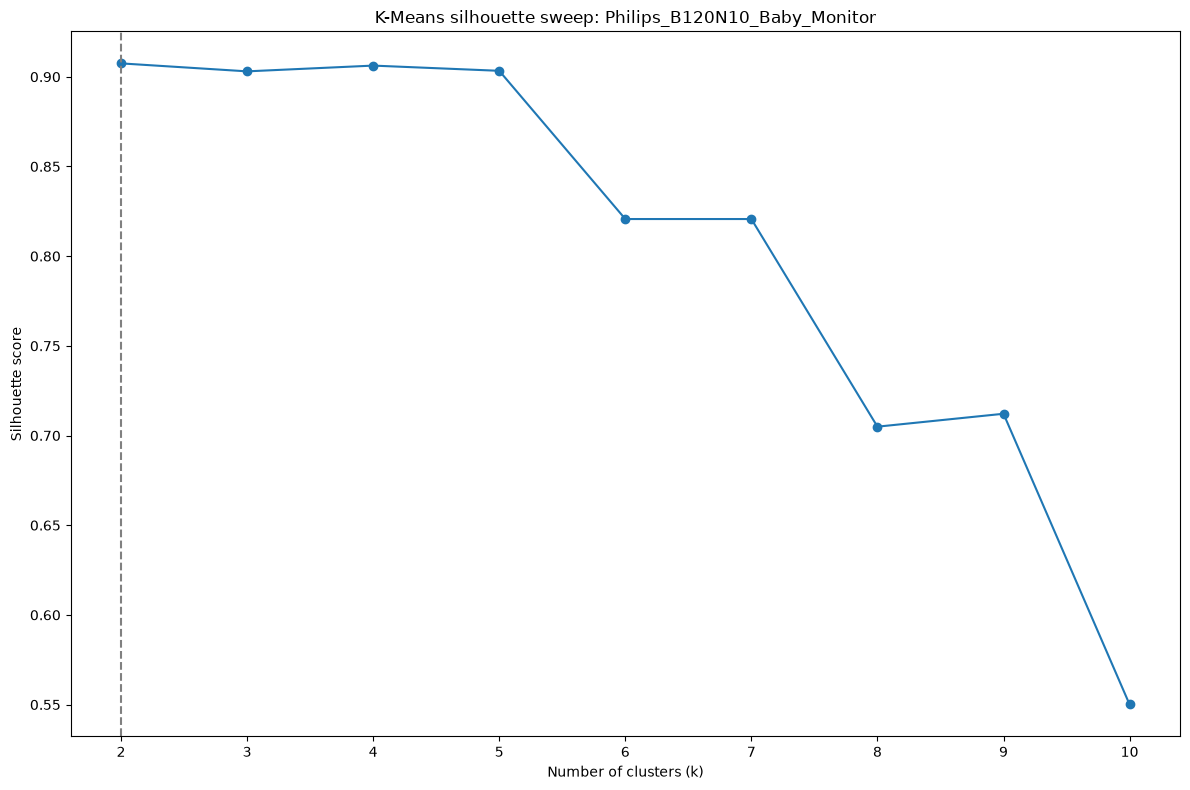

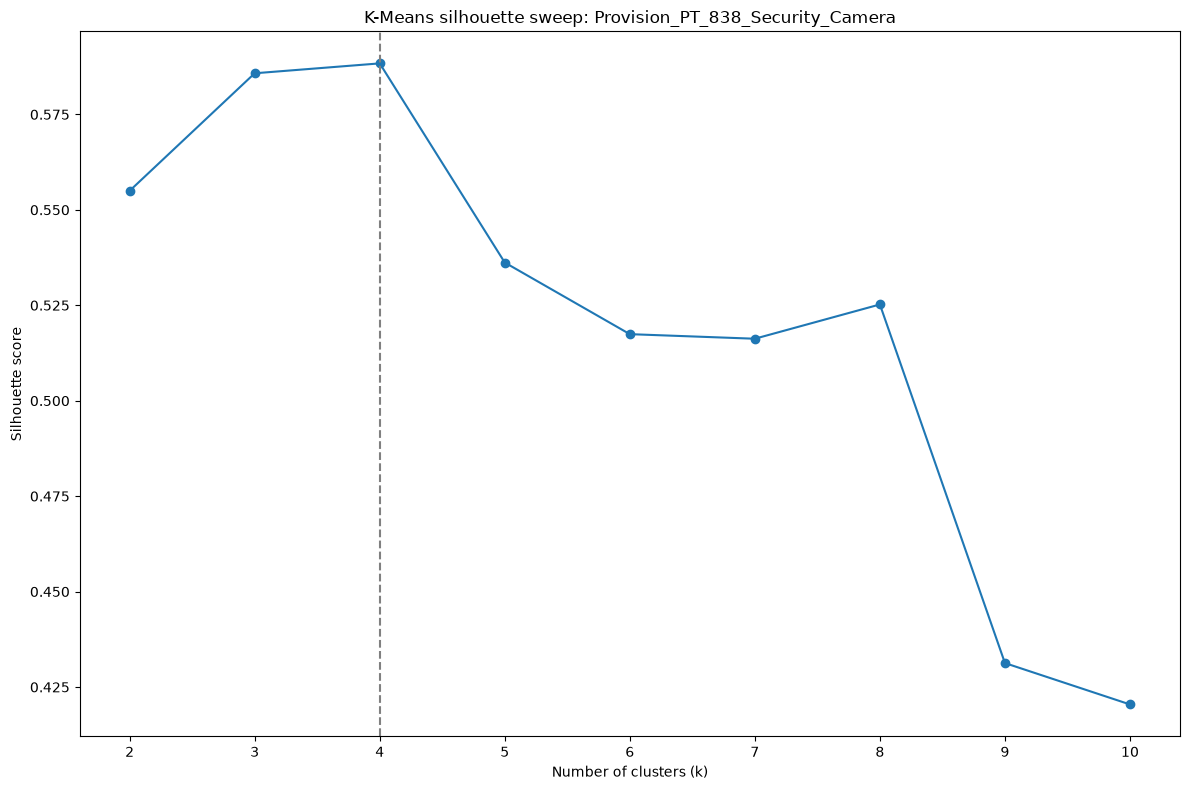

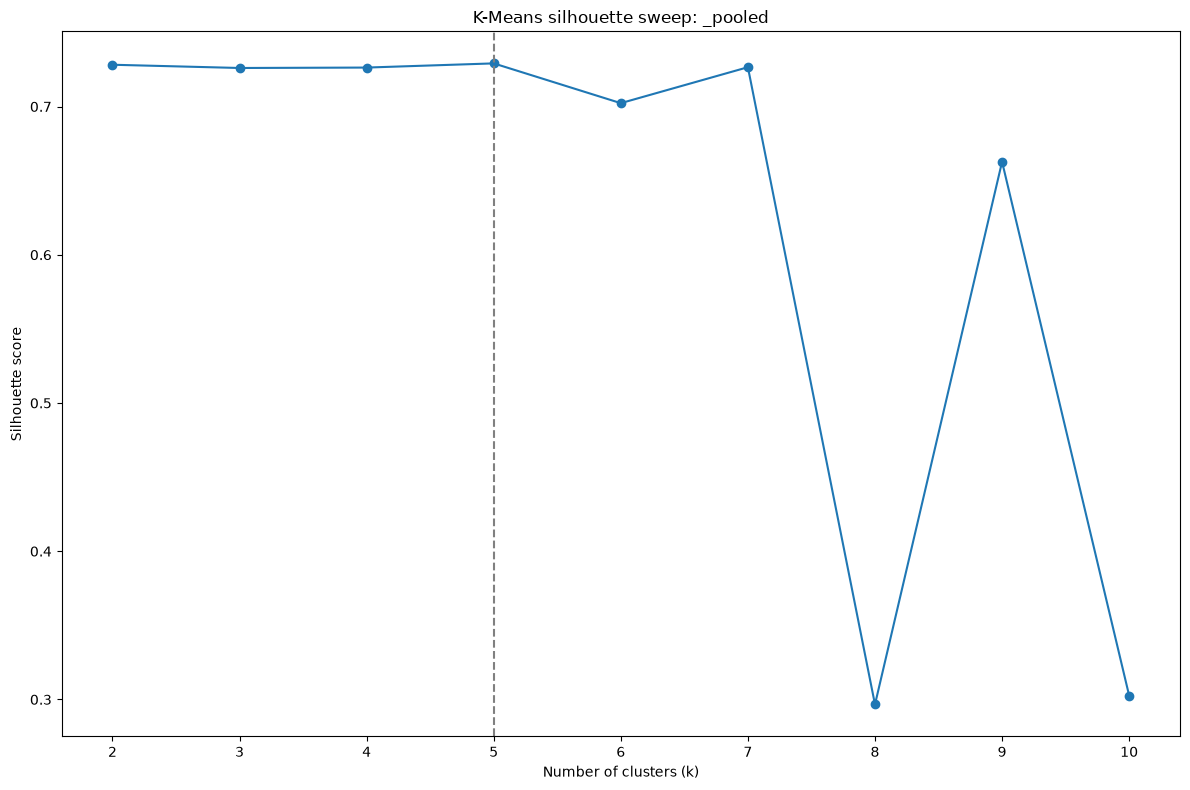

In [6]:
# Plot the silhouette score against k for every entry, marking the chosen k
for entry, result in kmeans_by_entry.items():
    k_values = list(result["silhouette_by_k"].keys())
    silhouette_values = list(result["silhouette_by_k"].values())

    figure, axis = plt.subplots(figsize=(12, 8))
    axis.plot(k_values, silhouette_values, marker="o")
    axis.axvline(result["best_k"], linestyle="--", color="grey")
    axis.set_title(f"K-Means silhouette sweep: {entry}")
    axis.set_xlabel("Number of clusters (k)")
    axis.set_ylabel("Silhouette score")
    figure.tight_layout()
    figure.savefig(Path(config.FIGURE_DIRECTORY) / f"clustering_silhouette_{entry}.png")
    plt.show()
    plt.close(figure)

## Score anomalies with K-Means

The anomaly score for a row is its distance to the nearest of the chosen model's cluster centroids, computed with `KMeans.transform`, which returns the distance to every centroid, and taking the smallest one per row. The alarm threshold is `mean + KMEANS_THRESHOLD_Z * std` of this distance measured on the **benign validation** rows only, never on train or test. A test row is predicted as an attack if its distance exceeds that threshold.

In [7]:
# Distance from every row to its nearest centroid, the K-Means anomaly score
def nearest_centroid_distance(model, X):
    return model.transform(X).min(axis=1)


# Score every entry: threshold from benign validation, predictions on test
for entry, arrays in entry_arrays.items():
    model = kmeans_by_entry[entry]["model"]

    train_distance = nearest_centroid_distance(model, arrays["X_train_clustering"])
    val_distance = nearest_centroid_distance(model, arrays["X_val_clustering"])
    threshold = val_distance.mean() + config.KMEANS_THRESHOLD_Z * val_distance.std()

    test_score = nearest_centroid_distance(model, arrays["X_test_clustering"])
    test_pred = (test_score > threshold).astype(int)

    kmeans_by_entry[entry]["threshold"] = threshold
    kmeans_by_entry[entry]["test_score"] = test_score
    kmeans_by_entry[entry]["test_pred"] = test_pred

    train_exceeding = (train_distance > threshold).mean()
    test_flagged = test_pred.mean()
    print(f"{entry}: Threshold={threshold:.3f}, Benign train already exceeding={train_exceeding:.1%}, Test flagged={test_flagged:.1%}")

Danmini_Doorbell: Threshold=15.071, Benign train already exceeding=0.9%, Test flagged=86.9%
Philips_B120N10_Baby_Monitor: Threshold=19.316, Benign train already exceeding=2.2%, Test flagged=62.7%
Provision_PT_838_Security_Camera: Threshold=10.181, Benign train already exceeding=1.2%, Test flagged=74.2%
_pooled: Threshold=13.676, Benign train already exceeding=1.3%, Test flagged=73.2%


## Choose DBSCAN's min_samples and compute each point's k-th neighbour distance

`min_samples` is set to `config.DBSCAN_MIN_SAMPLES_MULTIPLIER` times the number of PCA dimensions kept for that entry. Because the pooled case and each device kept a different number of PCA components, `min_samples` differs by entry: 44 for Danmini (22 dimensions), 38 for Philips and for the pooled case (19 dimensions each), and 30 for Provision (15 dimensions).

For every training point, the distance to its `min_samples`-th nearest neighbour is computed, including the point itself as one of its own neighbours, since that is exactly what DBSCAN's own rule for a core point tests against `eps`. The per-point distances are kept as-is, aligned to each row of `X_train_clustering`. They feed both the k-distance plot below (sorted, for that plot only) and the core-point derivation further down (unsorted, so each distance stays matched to its row).

In [8]:
# Distance from every row to its min_samples-th nearest neighbour, unsorted
def kth_neighbour_distance(X_train, min_samples):
    neighbours = NearestNeighbors(
        n_neighbors=min_samples, algorithm="kd_tree", n_jobs=1
    ).fit(X_train)
    distances, _ = neighbours.kneighbors(X_train)
    return distances[:, -1]


# Build the per-point k-th neighbour distance for every entry
dbscan_by_entry = {}
for entry, arrays in entry_arrays.items():
    number_of_dimensions = arrays["X_train_clustering"].shape[1]
    min_samples = config.DBSCAN_MIN_SAMPLES_MULTIPLIER * number_of_dimensions
    kth_distance = kth_neighbour_distance(arrays["X_train_clustering"], min_samples)
    dbscan_by_entry[entry] = {"min_samples": min_samples, "kth_distance": kth_distance}
    print(f"{entry}: Dimensions={number_of_dimensions}, min_samples={min_samples}")

Danmini_Doorbell: Dimensions=22, min_samples=44
Philips_B120N10_Baby_Monitor: Dimensions=19, min_samples=38
Provision_PT_838_Security_Camera: Dimensions=15, min_samples=30
_pooled: Dimensions=19, min_samples=38


## Choose eps from the k-distance plot

`eps` defaults to the `config.DBSCAN_EPS_PERCENTILE`-th percentile of the k-distance curve for every entry, computed automatically so the notebook always runs the same way from a clean restart. `config.DBSCAN_EPS_OVERRIDES` also lets a hand-picked `eps` replace that default for any entry, if the plot below is inspected later and an elbow is found to sit clearly elsewhere. It is empty for now, so every entry currently uses the automatic default. Both the default and, if set, the override are marked on the plot so the two can be compared against the true elbow by eye.

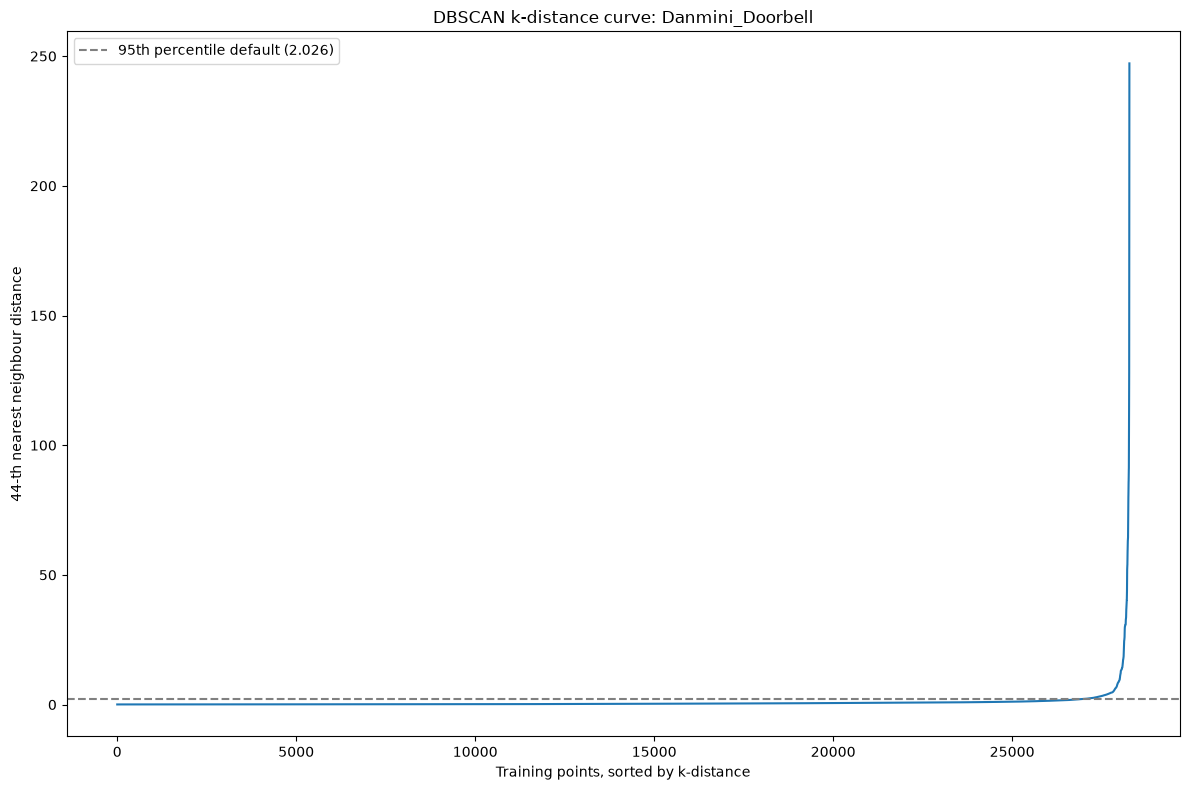

Danmini_Doorbell: eps=2.026 (default)


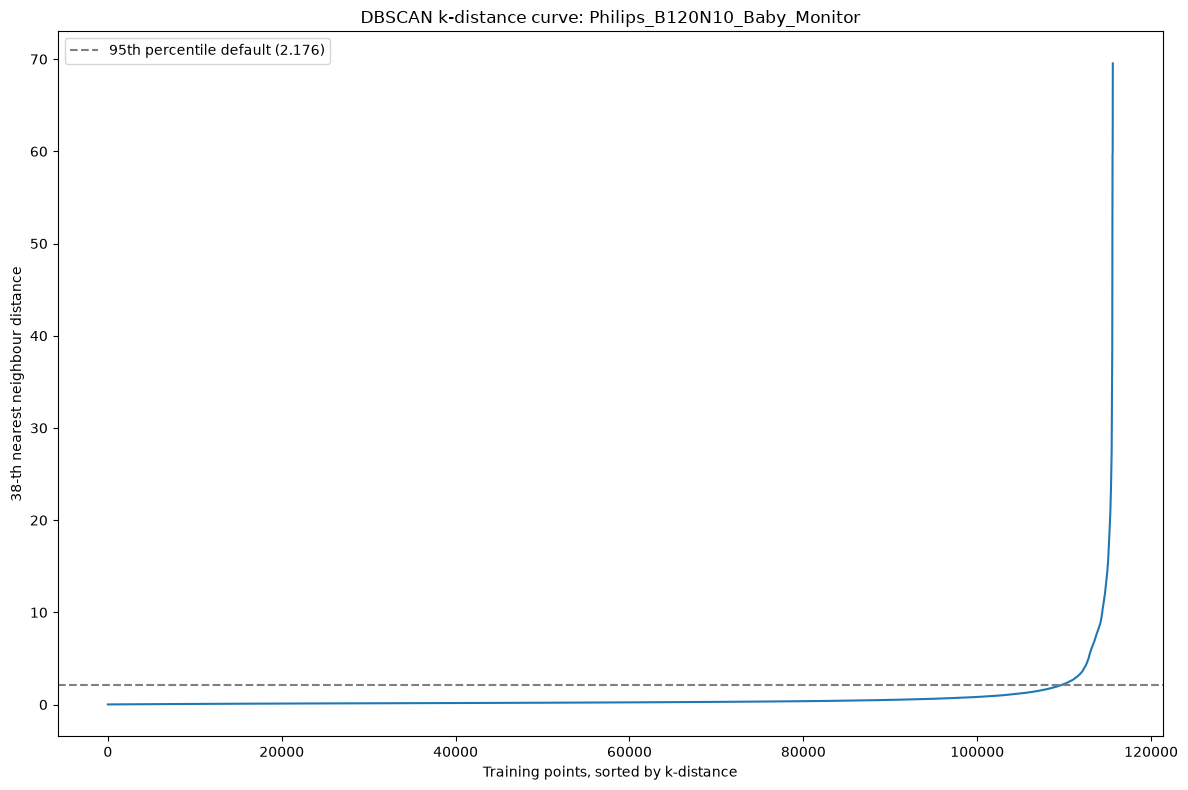

Philips_B120N10_Baby_Monitor: eps=2.176 (default)


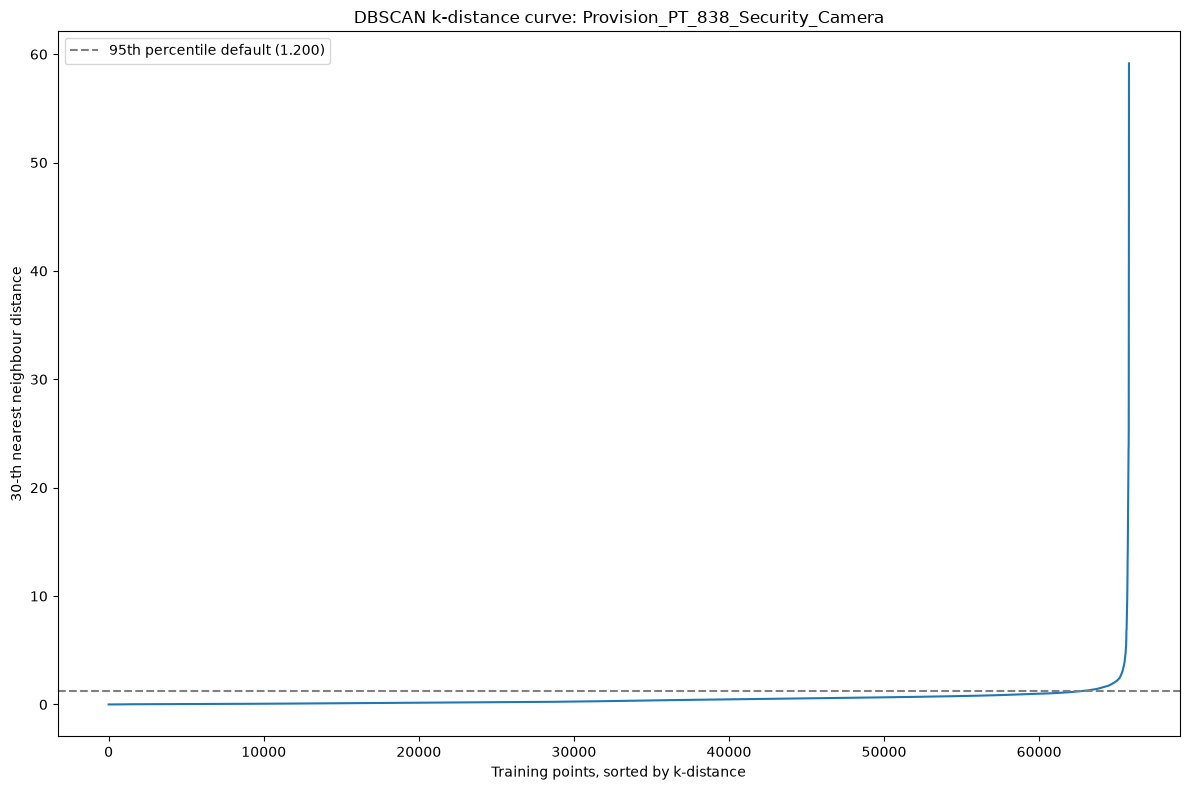

Provision_PT_838_Security_Camera: eps=1.200 (default)


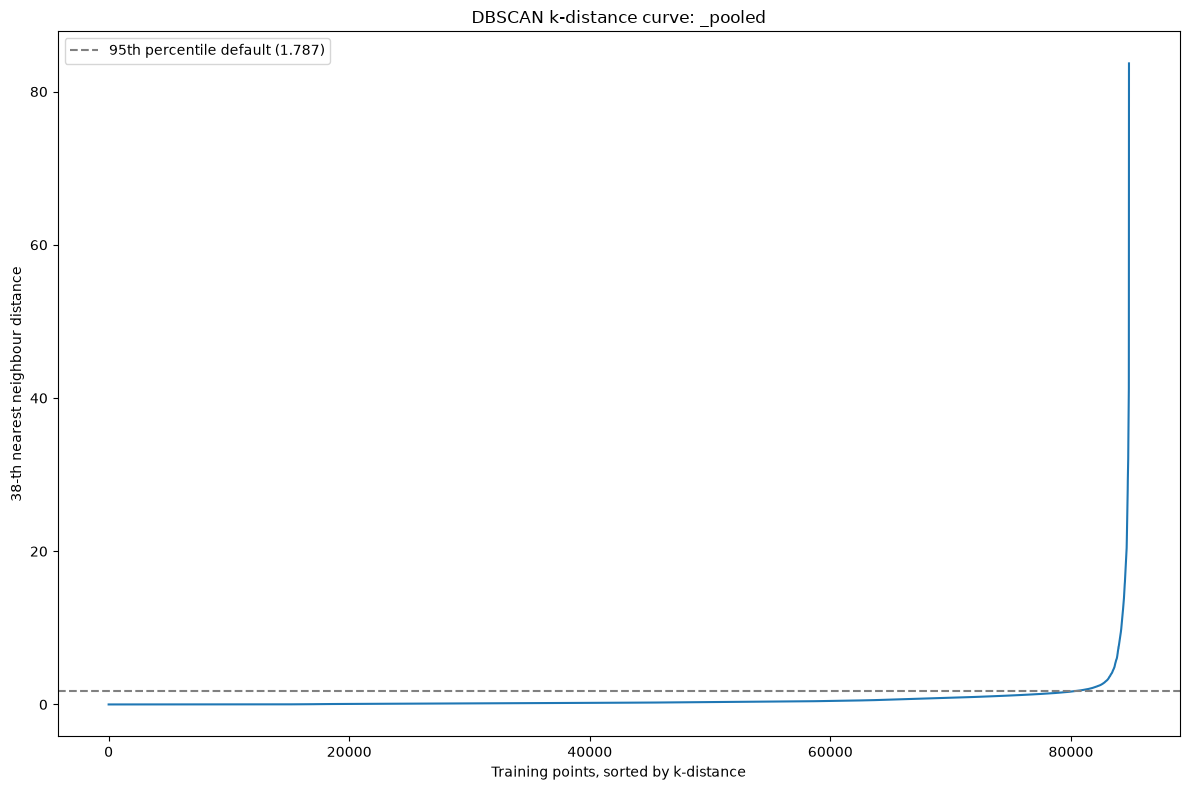

_pooled: eps=1.787 (default)


In [9]:
# Default eps from the k-distance curve, replaced by a manual override if one is set
for entry, result in dbscan_by_entry.items():
    kth_distance = result["kth_distance"]
    eps_default = np.percentile(kth_distance, config.DBSCAN_EPS_PERCENTILE)
    eps = config.DBSCAN_EPS_OVERRIDES.get(entry, eps_default)
    result["eps_default"] = eps_default
    result["eps"] = eps

    sorted_kth_distance = np.sort(kth_distance)
    figure, axis = plt.subplots(figsize=(12, 8))
    axis.plot(np.arange(len(sorted_kth_distance)), sorted_kth_distance)
    axis.axhline(eps_default, linestyle="--", color="grey", label=f"95th percentile default ({eps_default:.3f})")
    if entry in config.DBSCAN_EPS_OVERRIDES:
        axis.axhline(eps, linestyle="--", color="red", label=f"manual override ({eps:.3f})")
    axis.set_title(f"DBSCAN k-distance curve: {entry}")
    axis.set_xlabel("Training points, sorted by k-distance")
    axis.set_ylabel(f"{result['min_samples']}-th nearest neighbour distance")
    axis.legend()
    figure.tight_layout()
    figure.savefig(Path(config.FIGURE_DIRECTORY) / f"clustering_kdistance_{entry}.png")
    plt.show()
    plt.close(figure)

    eps_source = "override" if entry in config.DBSCAN_EPS_OVERRIDES else "default"
    print(f"{entry}: eps={eps:.3f} ({eps_source})")

## Derive DBSCAN's core points directly, without fitting DBSCAN

A point is a DBSCAN core point exactly when at least `min_samples` points, itself included, lie within `eps`. Equivalently, its `min_samples`-th nearest neighbour is no further than `eps`. That distance was already computed for every point above, so the core points can be read straight off it: `kth_distance <= eps`. This gives exactly the same set of points `DBSCAN.fit()` would mark as core, without ever building DBSCAN's own neighbour graph.

That graph is worth avoiding here, because its size depends on how many points fall within `eps` of each other, and with `eps` set to make roughly 95% of a benign training set count as core, the graph is nearly complete. A fixed-`k` neighbour search has none of that blow-up, since it always returns exactly `min_samples` distances per point regardless of how dense the data is. Measured directly on this project's largest entry, `DBSCAN.fit()` took over fifteen minutes and had previously exhausted system memory outright, while the equivalent mask built from `kth_distance` takes a fraction of a second. Before relying on this shortcut here, it was checked to be byte-for-byte equivalent to `DBSCAN.fit()`'s own `core_sample_indices_` on an entry small enough to fit directly.

Cluster count and noise fraction, which only an actual `DBSCAN.fit()` could report, are not available from this shortcut and are not computed here.

If the automatic `eps` happens to be too small for an entry, every training point could fall outside the mask, leaving no core point for any later row to be compared against. This is checked for immediately, and if it happens, the notebook stops with a message naming the entry and pointing at the k-distance plot and the `config.DBSCAN_EPS_OVERRIDES` entry to add, instead of continuing on to a meaningless score.

In [10]:
# Core points are exactly those whose min_samples-th neighbour lies within eps
for entry, arrays in entry_arrays.items():
    result = dbscan_by_entry[entry]
    core_mask = result["kth_distance"] <= result["eps"]

    assert core_mask.sum() > 0, (
        f"No core points for {entry} with eps: {result['eps']:.4f} "
        f"(min_samples: {result['min_samples']}). "
        f"Inspect reports/figures/clustering_kdistance_{entry}.png and add "
        f"a hand-picked eps to config.DBSCAN_EPS_OVERRIDES['{entry}']."
    )

    core_fraction = core_mask.mean()
    result["core_mask"] = core_mask
    result["core_fraction"] = core_fraction
    print(f"{entry}: Core points={core_fraction:.1%}")

Danmini_Doorbell: Core points=95.0%
Philips_B120N10_Baby_Monitor: Core points=95.0%
Provision_PT_838_Security_Camera: Core points=95.0%
_pooled: Core points=95.0%


## Score anomalies with DBSCAN

The anomaly score for a row is its distance to the nearest **core** training point, not to any training point and not merely to a non-noise one, since a border point is only ever within reach of a core point and is not itself dense. A row is predicted as an attack if that distance exceeds `eps`.

This threshold is not calibrated the same way as K-Means's. `eps` comes from the **training** k-distance curve, while K-Means's threshold above comes from **benign validation** distances. A threshold read off the same data a model was fit on is optimistic, so DBSCAN's fixed operating point and K-Means's are not on equal footing. This is a deliberate, documented limitation, not an oversight. `eps` is DBSCAN's standard, spec-defined operating point, and giving it a second, validation-based threshold instead would add a free parameter the project does not otherwise use. As a cheap way to keep the two comparable, DBSCAN's flagged fraction on benign validation rows is computed below too and carried into the summary table, so it can be read alongside K-Means's threshold behaviour even though it isn't DBSCAN's actual operating point. Because DBSCAN's `eps` is train-derived while K-Means's threshold is validation-derived, the model comparison in the evaluation notebook should lean on ROC-AUC, which does not depend on either fixed threshold, and treat fixed-threshold precision, recall, and false-positive rate as secondary.

Scoring below relies on `core_mask` already being non-empty, which the previous cell's guardrail exists specifically to guarantee. This scoring step is written to run only after that guardrail, by design, so a later reordering of these cells cannot silently skip the check it depends on.

In [11]:
# Distance from every row to the nearest DBSCAN core training point
def nearest_core_distance(core_points, X):
    neighbours = NearestNeighbors(n_neighbors=1, algorithm="kd_tree", n_jobs=1).fit(core_points)
    distances, _ = neighbours.kneighbors(X)
    return distances[:, 0]


# DBSCAN's eps is train-derived, K-Means's threshold is validation-derived (compare via ROC-AUC first, fixed-threshold FPR/recall second)
for entry, arrays in entry_arrays.items():
    result = dbscan_by_entry[entry]
    core_points = arrays["X_train_clustering"][result["core_mask"]]

    val_score = nearest_core_distance(core_points, arrays["X_val_clustering"])
    val_flagged_fraction = (val_score > result["eps"]).mean()

    test_score = nearest_core_distance(core_points, arrays["X_test_clustering"])
    test_pred = (test_score > result["eps"]).astype(int)

    result["val_flagged_fraction"] = val_flagged_fraction
    result["test_score"] = test_score
    result["test_pred"] = test_pred
    print(f"{entry}: Benign validation flagged={val_flagged_fraction:.1%}, Test flagged={test_pred.mean():.1%}")

Danmini_Doorbell: Benign validation flagged=3.4%, Test flagged=87.3%
Philips_B120N10_Baby_Monitor: Benign validation flagged=3.9%, Test flagged=63.2%
Provision_PT_838_Security_Camera: Benign validation flagged=2.2%, Test flagged=59.7%
_pooled: Benign validation flagged=2.9%, Test flagged=59.3%


## Save each entry's scores and predictions

The K-Means and DBSCAN test scores and predictions built above are written to each entry's processed folder, ready for the evaluation notebook to load without recomputing anything.

In [12]:
# Save every entry's K-Means and DBSCAN test scores and predictions
for entry in entries:
    config.save_arrays(
        entry,
        kmeans_score=kmeans_by_entry[entry]["test_score"],
        kmeans_pred=kmeans_by_entry[entry]["test_pred"],
        dbscan_score=dbscan_by_entry[entry]["test_score"],
        dbscan_pred=dbscan_by_entry[entry]["test_pred"],
    )

## Verify the saved outputs

Everything just written is reloaded from disk and checked. Every array's row count must match that entry's test row count, and every prediction array must contain only 0s and 1s. A summary table is built from the reloaded arrays and the choices made above, as a headline view of both detectors across every entry.

In [13]:
# Reload every saved array and check shapes and prediction values
summary_rows = []
for entry, arrays in entry_arrays.items():
    reloaded = config.load_arrays(entry, "kmeans_score", "kmeans_pred", "dbscan_score", "dbscan_pred")
    test_rows = arrays["X_test_clustering"].shape[0]

    for name, array in reloaded.items():
        assert array.shape[0] == test_rows

    assert set(np.unique(reloaded["kmeans_pred"])) <= {0, 1}
    assert set(np.unique(reloaded["dbscan_pred"])) <= {0, 1}

    kmeans_result = kmeans_by_entry[entry]
    dbscan_result = dbscan_by_entry[entry]
    eps_source = "override" if entry in config.DBSCAN_EPS_OVERRIDES else "default"
    summary_rows.append({
        "entry": entry,
        "kmeans_best_k": kmeans_result["best_k"],
        "kmeans_threshold": kmeans_result["threshold"],
        "kmeans_test_flagged": reloaded["kmeans_pred"].mean(),
        "dbscan_min_samples": dbscan_result["min_samples"],
        "dbscan_eps": dbscan_result["eps"],
        "dbscan_eps_source": eps_source,
        "dbscan_core_fraction": dbscan_result["core_fraction"],
        "dbscan_val_flagged_fraction": dbscan_result["val_flagged_fraction"],
        "dbscan_test_flagged": reloaded["dbscan_pred"].mean(),
    })

pd.DataFrame(summary_rows)

,entry,kmeans_best_k,kmeans_threshold,kmeans_test_flagged,dbscan_min_samples,dbscan_eps,dbscan_eps_source,dbscan_core_fraction,dbscan_val_flagged_fraction,dbscan_test_flagged
0,Danmini_Doorbell,6,15.071155,0.869475,44,2.025713,default,0.949993,0.033834,0.872710
1,Philips_B120N10_Baby_Monitor,2,19.316263,0.626567,38,2.176330,default,0.949999,0.039199,0.632048
2,Provision_PT_838_Security_Camera,4,10.181378,0.742015,30,1.199640,default,0.949997,0.021704,0.597357
3,_pooled,5,13.675607,0.732253,38,1.787274,default,0.949993,0.028663,0.593202


## Confirm every expected file exists

A final sweep checks that all sixteen expected files, the four K-Means and DBSCAN score and prediction arrays for every entry, are actually present on disk.

In [14]:
# Sweep every expected file for every entry and confirm it exists
expected_file_names = ["kmeans_score.npy", "kmeans_pred.npy", "dbscan_score.npy", "dbscan_pred.npy"]

missing_files = []
for entry in entries:
    for file_name in expected_file_names:
        if not (Path(config.PROCESSED_DIRECTORY) / entry / file_name).exists():
            missing_files.append(f"data/processed/{entry}/{file_name}")

assert not missing_files, f"Missing files: {missing_files}"
print(f"All {len(entries) * len(expected_file_names)} expected files are present.")

All 16 expected files are present.
